# COMP3710 Lab 1 - Sierpinski Triangle

This notebook implements a GPU-accelerated Sierpinski Triangle using PyTorch.

## Project goals

- Generate the Sierpinski Triangle using vectorised PyTorch operations.
- Process pixel coordinates in parallel on the GPU.
- Compare different recursion depths.
- Create different colour visualisations.
- Estimate the box-counting dimension.
- Compare the estimated dimension with the theoretical dimension.
- Compare CPU and GPU execution times.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
Device: cuda
GPU name: Tesla T4


## 1. Basic Sierpinski Triangle Generation

The Sierpinski Triangle can be constructed by repeatedly creating three half-sized copies of the current point set, positioned towards the three vertices of a triangle.

At every recursion level, PyTorch uses broadcasting to generate the three new point groups in parallel.

In [2]:
def generate_sierpinski_triangle(depth, computation_device):
    """
    Generate points belonging to a Sierpinski Triangle.
    生成谢尔宾斯基三角形中的所有点。

    Parameters
    ----------
    depth : int
        Number of recursion levels.
        递归深度。

    computation_device : torch.device
        Device used for tensor calculations.
        Tensor计算使用的设备，例如CPU或GPU。

    Returns
    -------
    torch.Tensor
        Point coordinates with shape [number_of_points, 2].
        形状为[点的数量, 2]的坐标Tensor。
    """

    # 等边三角形的高度 / Height of an equilateral triangle
    triangle_height = (3.0 ** 0.5) / 2.0

    # 三角形的三个顶点：左下、右下、顶部
    # Three vertices: bottom-left, bottom-right and top
    vertices = torch.tensor(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.5, triangle_height]
        ],
        dtype=torch.float32,
        device=computation_device
    )

    # 从三角形中心的一个点开始
    # Start with one point at the centre of the triangle
    points = torch.tensor(
        [[0.5, triangle_height / 3.0]],
        dtype=torch.float32,
        device=computation_device
    )

    # 每次递归都会让每个旧点产生三个新点
    # Each recursion makes every existing point produce three new points
    for _ in range(depth):

        # points[:, None, :] 的形状是 [N, 1, 2]
        # vertices[None, :, :] 的形状是 [1, 3, 2]
        #
        # PyTorch广播会一次并行计算N个点到三个顶点的中点
        # Broadcasting calculates the three new point groups in parallel
        points = (points[:, None, :] + vertices[None, :, :]) / 2.0

        # 把形状从[N, 3, 2]重新整理为[3N, 2]
        # Reshape the result from [N, 3, 2] to [3N, 2]
        points = points.reshape(-1, 2)

    return points

Recursion depth: 10
Number of points: 59049
Expected number of points: 59049
Tensor device: cuda:0


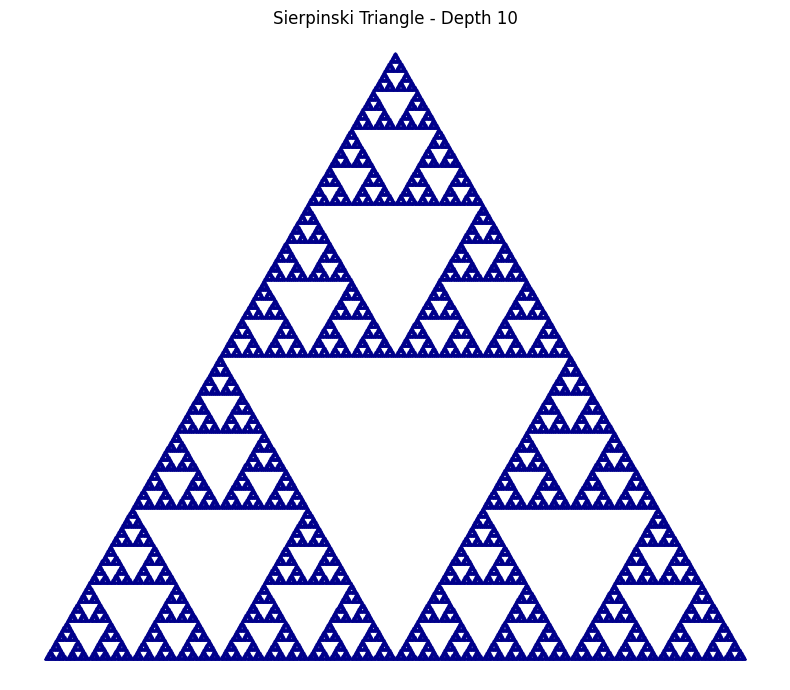

In [3]:
# 设置递归深度 / Set the recursion depth
depth = 10

# 使用前面选择的device生成分形
# Generate the fractal using the selected device
sierpinski_points = generate_sierpinski_triangle(depth, device)

# 输出运行信息，方便Demo时证明结果正确
# Display information for verification during the demo
print("Recursion depth:", depth)
print("Number of points:", sierpinski_points.shape[0])
print("Expected number of points:", 3 ** depth)
print("Tensor device:", sierpinski_points.device)

# Matplotlib不能直接绘制CUDA Tensor
# 所以只在绘图前把结果移回CPU并转换成NumPy数组
# Matplotlib cannot directly plot a CUDA tensor,
# so the result is moved to the CPU only for plotting
points_for_plotting = sierpinski_points.detach().cpu().numpy()

# 创建图像 / Create the plot
plt.figure(figsize=(8, 7))

plt.scatter(
    points_for_plotting[:, 0],
    points_for_plotting[:, 1],
    s=0.5,
    color="darkblue"
)

plt.title(f"Sierpinski Triangle - Depth {depth}")

# 保持横轴和纵轴比例相同，避免三角形变形
# Keep equal axis scaling to avoid distorting the triangle
plt.axis("equal")

# 隐藏坐标轴，使分形图更清晰
# Hide the axes for a clearer visualisation
plt.axis("off")

plt.tight_layout()
plt.show()

## Comparison of recursion depths

The visualisations below compare Sierpinski Triangles at different recursion depths. Each additional recursion level replaces every existing point with three new points, so the total number of points is \(3^d\), where \(d\) is the recursion depth.

下面的图像比较不同递归深度的谢尔宾斯基三角形。每增加一层递归，每个已有点都会产生三个新点，因此深度为 \(d\) 时总点数是 \(3^d\)。

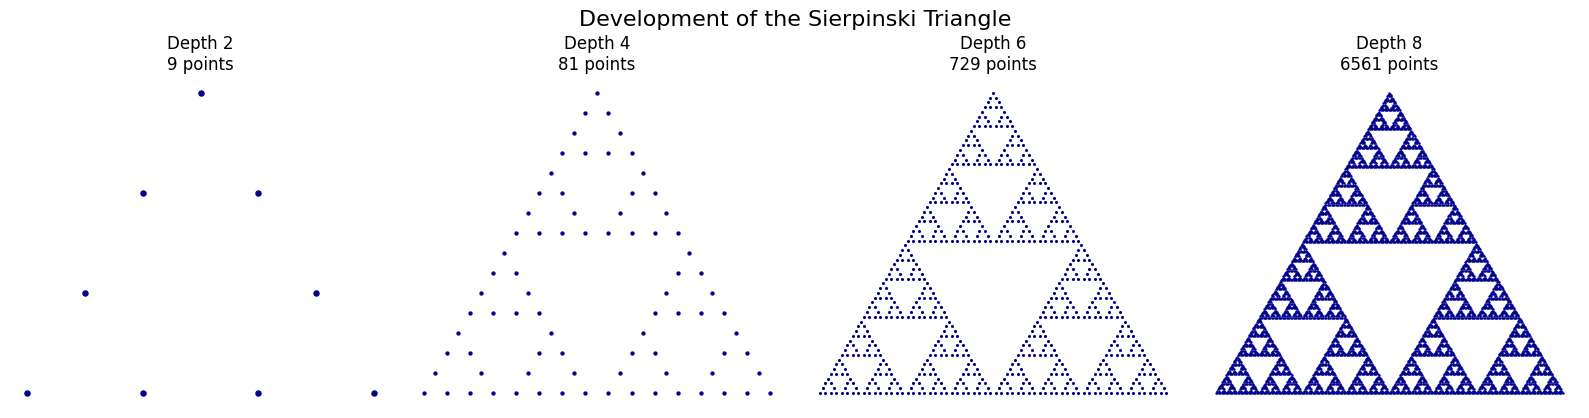

In [4]:
# 选择四个不同的递归深度进行比较
# Select four different recursion depths for comparison
comparison_depths = [2, 4, 6, 8]

# 创建一行四列的图像区域
# Create a figure containing one row and four columns
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

# 分别生成并绘制每一个递归深度
# Generate and plot each recursion depth
for axis, current_depth in zip(axes, comparison_depths):

    # 使用PyTorch函数在所选设备上生成坐标
    # Generate point coordinates on the selected PyTorch device
    current_points = generate_sierpinski_triangle(
        current_depth,
        device
    )

    # Matplotlib绘图前，把CUDA Tensor移动到CPU
    # Move the CUDA tensor to the CPU before plotting with Matplotlib
    current_points_for_plotting = (
        current_points
        .detach()
        .cpu()
        .numpy()
    )

    # 递归深度较小时使用较大的点，深度较大时使用较小的点
    # Use larger markers for small depths and smaller markers for large depths
    point_size = max(
        0.2,
        40 / (3 ** (current_depth / 2))
    )

    axis.scatter(
        current_points_for_plotting[:, 0],
        current_points_for_plotting[:, 1],
        s=point_size,
        color="darkblue"
    )

    # 标题同时显示递归深度和点的数量
    # Display both the recursion depth and number of points
    axis.set_title(
        f"Depth {current_depth}\n"
        f"{current_points.shape[0]} points"
    )

    # 保持三角形比例并隐藏坐标轴
    # Preserve the triangle shape and hide the axes
    axis.set_aspect("equal")
    axis.axis("off")

# 添加整张比较图的标题
# Add a title for the complete comparison
plt.suptitle(
    "Development of the Sierpinski Triangle",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Coordinate-based colour visualisations

The same Sierpinski Triangle can be visualised using different colour mappings. The first plot maps colour to the horizontal coordinate \(x\), while the second plot maps colour to the vertical coordinate \(y\). These colour mappings make the spatial distribution of the generated points easier to interpret.

同一个谢尔宾斯基三角形可以使用不同的颜色映射显示。第一张图根据横坐标 \(x\) 上色，第二张图根据纵坐标 \(y\) 上色。颜色映射可以帮助我们更直观地观察生成点的空间分布。

Colour visualisation depth: 9
Number of points: 19683
Tensor device: cuda:0


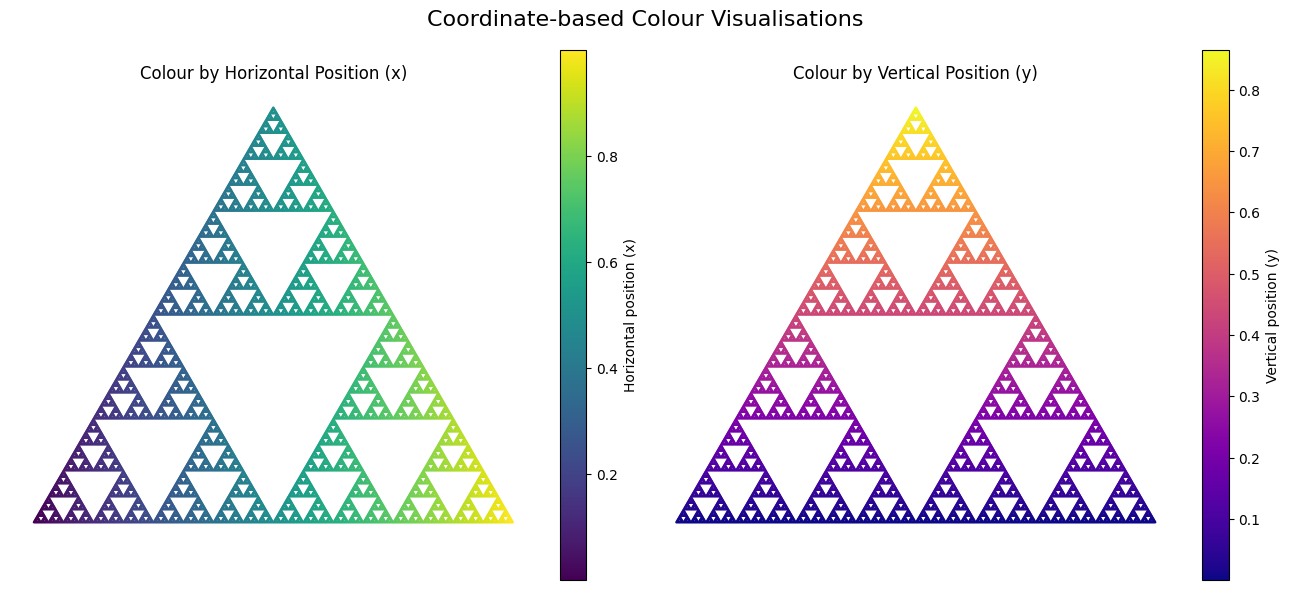

In [5]:
# 设置颜色可视化使用的递归深度
# Set the recursion depth used for colour visualisation
colour_depth = 9

# 使用PyTorch在所选设备上生成分形坐标
# Generate the fractal coordinates using PyTorch on the selected device
colour_points_tensor = generate_sierpinski_triangle(
    colour_depth,
    device
)

# 输出信息，证明坐标是在GPU上生成的
# Print information to verify that the coordinates were generated on the GPU
print("Colour visualisation depth:", colour_depth)
print("Number of points:", colour_points_tensor.shape[0])
print("Tensor device:", colour_points_tensor.device)

# Matplotlib需要CPU上的NumPy数组
# Matplotlib requires a NumPy array stored on the CPU
colour_points = (
    colour_points_tensor
    .detach()
    .cpu()
    .numpy()
)

# 创建一行两列的图像区域
# Create a figure containing one row and two columns
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# 第一张图：根据横坐标x设置颜色
# First plot: map colour to the horizontal x-coordinate
horizontal_plot = axes[0].scatter(
    colour_points[:, 0],
    colour_points[:, 1],
    c=colour_points[:, 0],
    cmap="viridis",
    s=0.5
)

axes[0].set_title("Colour by Horizontal Position (x)")
axes[0].set_aspect("equal")
axes[0].axis("off")

# 添加横坐标颜色条
# Add a colour bar for the horizontal coordinate
horizontal_colourbar = fig.colorbar(
    horizontal_plot,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)
horizontal_colourbar.set_label("Horizontal position (x)")

# 第二张图：根据纵坐标y设置颜色
# Second plot: map colour to the vertical y-coordinate
vertical_plot = axes[1].scatter(
    colour_points[:, 0],
    colour_points[:, 1],
    c=colour_points[:, 1],
    cmap="plasma",
    s=0.5
)

axes[1].set_title("Colour by Vertical Position (y)")
axes[1].set_aspect("equal")
axes[1].axis("off")

# 添加纵坐标颜色条
# Add a colour bar for the vertical coordinate
vertical_colourbar = fig.colorbar(
    vertical_plot,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)
vertical_colourbar.set_label("Vertical position (y)")

# 添加整张图的标题
# Add a title for the complete visualisation
plt.suptitle(
    "Coordinate-based Colour Visualisations",
    fontsize=16
)

plt.tight_layout()
plt.show()